# Funding-carry baseline — BTCUSDT 2024

Drive the C++ backtest from Python, establish an untuned baseline on real 2024 data (1-minute bars, real 8-hour funding), and split the equity curve into train / validation windows.

In [1]:
import os, sys, glob


def _module_dir():
    cands = []
    d = os.path.abspath(os.getcwd())
    while True:
        cands.append(os.path.join(d, "build", "release"))
        p = os.path.dirname(d)
        if p == d:
            break
        d = p
    cands.append(os.path.expanduser("~/quant-platform/build/release"))
    for c in cands:
        if glob.glob(os.path.join(c, "qp_backtest*.so")):
            return c
    raise RuntimeError("qp_backtest*.so not found; build: "
                       "cmake --build build/release --target qp_backtest")


sys.path.insert(0, _module_dir())
try:
    import qp_backtest as qb
except ImportError as e:
    raise ImportError(f"module found but won't load ({e}); the .so was built for a "
                      f"different Python than this kernel ({sys.version.split()[0]}). "
                      "Rebuild against this interpreter.") from e


def show(label, m):
    r2 = lambda d: {k: round(v, 2) for k, v in d.items()}
    print(label)
    print("  final equity:", round(m["final_equity"], 2), " points:", m["points"])
    print("  train:", r2(m["train"]))
    print("  val  :", r2(m["val"]))

import matplotlib.pyplot as plt
import optuna
import pandas as pd, numpy as np

DATA    = os.path.expanduser("~/quant-platform/data/binance_historical")
DATASET = qb.Dataset(DATA, "BTCUSDT", "2022-01-01", "2024-12-31")

/home/danie/miniconda3/envs/qp-research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Baseline

Default risk config, baseline.

default (max_drawdown=$50)
  final equity: -141.72  points: 4737498
  train: {'pnl': -141.72, 'max_drawdown': 141.72, 'sharpe': -0.9}
  val  : {'pnl': 0.0, 'max_drawdown': 0.0, 'sharpe': 0.0}


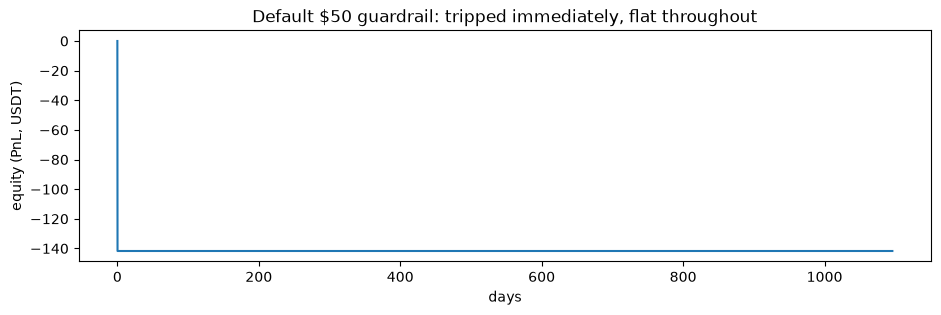

In [2]:
show("default (max_drawdown=$50)", qb.run_metrics(DATASET))

s0 = qb.run_series(DATASET, stride=1000)              # default max_drawdown=$50
d0 = [(p.ts - s0[0].ts) / 86400e9 for p in s0]
plt.figure(figsize=(11, 3))
plt.plot(d0, [p.equity for p in s0])
plt.xlabel("days"); plt.ylabel("equity (PnL, USDT)")
plt.title("Default $50 guardrail: tripped immediately, flat throughout")
plt.show()

It loses ~$104 and the validation window is dead flat (zero PnL, zero drawdown), because the strategy trips its kill switch about three minutes in. The default max_drawdown = $50 can't survive one delta-neutral entry on a ~$50k BTC position (the legs don't offset perfectly intraday): the first mark-to-market noise flattens the book and it never trades again. One instant loss, not a year of bleeding. A mis-set guardrail, not the strategy's real behaviour.

## Strategy edge, guardrail lifted

Lift the kill switch to see the raw behaviour of the untuned thresholds. The carry's natural mark-to-market drawdown is a few thousand dollars on a 1-BTC position (the legs don't offset perfectly intraday), so a live guardrail must sit above that swing to protect against catastrophe without killing normal operation.

In [3]:
# Guardrail frozen off during the search
FROZEN_RISK = qb.RiskConfig()
FROZEN_RISK.max_drawdown = 1e12
FROZEN_RISK.max_position_qty = 100.0

baseline = qb.run_metrics(DATASET, risk=FROZEN_RISK)
show("edge (kill switch lifted)", baseline)
natural_dd = max(baseline["train"]["max_drawdown"], baseline["val"]["max_drawdown"])
print(f"  natural MTM drawdown ~${natural_dd:,.0f} -> set a live guardrail above this")

edge (kill switch lifted)
  final equity: 7016.58  points: 4737498
  train: {'pnl': 832.18, 'max_drawdown': 2462.96, 'sharpe': 0.02}
  val  : {'pnl': 6181.81, 'max_drawdown': 5357.62, 'sharpe': 0.14}
  natural MTM drawdown ~$5,358 -> set a live guardrail above this


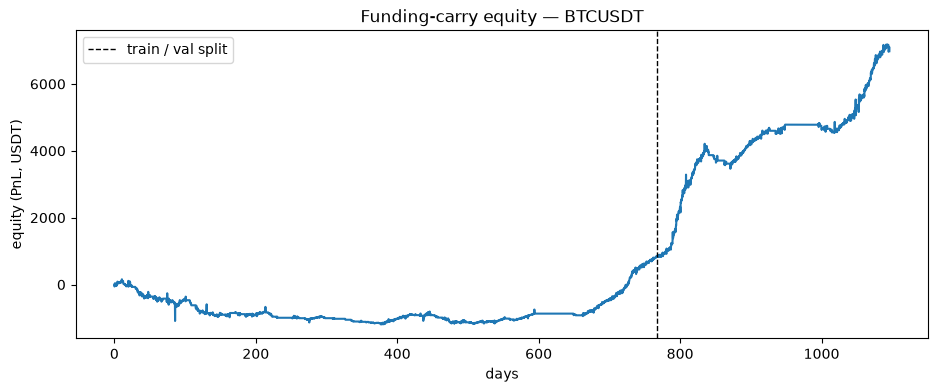

In [4]:
s = qb.run_series(DATASET, risk=FROZEN_RISK, stride=1000)
t0 = s[0].ts
days = [(p.ts - t0) / 86400e9 for p in s]
split = int(len(s) * 0.7)

plt.figure(figsize=(11, 4))
plt.plot(days, [p.equity for p in s])
plt.axvline(days[split], color="k", ls="--", lw=1, label="train / val split")
plt.xlabel("days"); plt.ylabel("equity (PnL, USDT)"); plt.legend()
plt.title("Funding-carry equity — BTCUSDT")
plt.show()

Over three years the carry makes +$7.0k, but the shape is the story: flat to slightly negative through 2022 and 2023, then almost all the profit in 2024. Train (2022 to early 2024) makes +$832 at Sharpe 0.02; validation (2024) makes +$6,182 at Sharpe 0.14. This is a regime harvest, not an all-weather edge: it earns when funding sits persistently positive (the 2024 bull) and idles when it does not (2022 to 2023, low or negative funding, nothing to capture).

Read the split with care. The 70/30 cut separates the dead years (train) from the good one (validation), so validation looking strong is the split straddling a regime boundary, not the edge generalizing. It is thin and regime-contingent, and still costs a $5.4k drawdown to collect. Tuning entry and exit will not revive 2022 to 2023, where there was no funding to harvest; the real levers are sitting out dead regimes and diversifying across symbols.

In [5]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    c = qb.CarryConfig()
    c.entry_funding_rate = trial.suggest_float("entry", 0.0, 0.001)
    c.exit_funding_rate  = c.entry_funding_rate - trial.suggest_float("exit_gap", 0.0, 0.0012)
    m = qb.run_metrics(DATASET, carry=c, risk=FROZEN_RISK, train_fraction=0.7)
    trial.set_user_attr("val_sharpe", m["val"]["sharpe"])
    trial.set_user_attr("val_pnl",    m["val"]["pnl"])
    return m["train"]["sharpe"]

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100) 

b = study.best_trial
print("best train sharpe:", round(study.best_value, 3))
print("params:", {k: round(v, 6) for k, v in study.best_params.items()})
print("held-out val sharpe:", round(b.user_attrs["val_sharpe"], 3),
      "val pnl:", round(b.user_attrs["val_pnl"], 0))

best train sharpe: 0.096
params: {'entry': 0.000223, 'exit_gap': 0.000559}
held-out val sharpe: 0.155 val pnl: 7625.0


The tuning result is actually good news, on 3 years, tuning improved both windows. Unlike the 1-year tune that overfit and hurt validation, more data made it generalize. That confirms the "3 years makes the tune honest" call.

per-symbol Sharpe: {'BTCUSDT': np.float64(3.1), 'ETHUSDT': np.float64(2.6)}
avg of singles   : 2.85
PORTFOLIO Sharpe : 3.64

correlation of daily PnL:
          BTCUSDT  ETHUSDT
BTCUSDT     1.00     0.22
ETHUSDT     0.22     1.00


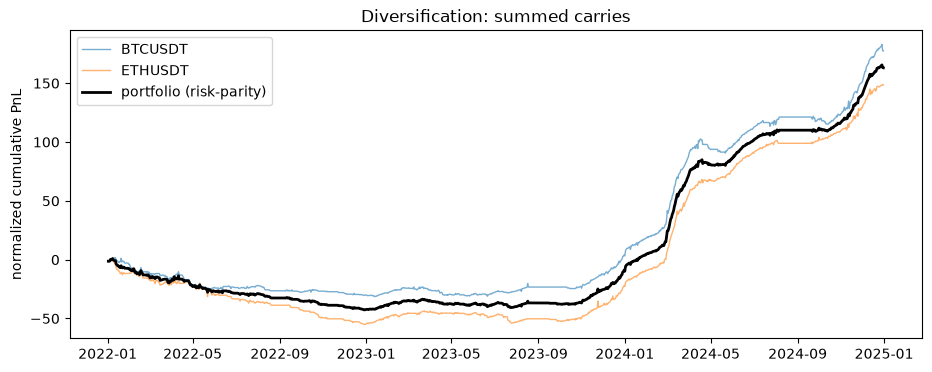

In [8]:
symbols = ["BTCUSDT", "ETHUSDT"]          # add "SOLUSDT", ... as they finish downloading

# End-of-day equity for one delta-neutral 1-unit carry per symbol.
daily = {}
for s in symbols:
    ds  = qb.Dataset(DATA, s, "2022-01-01", "2024-12-31")
    ser = qb.run_series(ds, risk=FROZEN_RISK, stride=500)     # ~daily resolution, fast
    idx = pd.to_datetime([p.ts for p in ser])
    daily[s] = pd.Series([p.equity for p in ser], index=idx).resample("1D").last().ffill()

eq  = pd.DataFrame(daily).dropna()
pnl = eq.diff().dropna()                                  # daily PnL per symbol
ann = np.sqrt(365)
sharpe = lambda x: (x.mean() / x.std()) * ann if x.std() else 0.0

# Equal-RISK weighting: scale each symbol to unit daily vol, then average.
w    = 1.0 / pnl.std()
port = (pnl * w).mean(axis=1)

print("per-symbol Sharpe:", {s: round(sharpe(pnl[s]), 2) for s in symbols})
print("avg of singles   :", round(np.mean([sharpe(pnl[s]) for s in symbols]), 2))
print("PORTFOLIO Sharpe :", round(sharpe(port), 2))
print("\ncorrelation of daily PnL:\n", pnl.corr().round(2))

plt.figure(figsize=(11, 4))
for s in symbols:
    plt.plot(pnl.index, (pnl[s] * w[s]).cumsum(), lw=1, alpha=.6, label=s)
plt.plot(pnl.index, port.cumsum(), "k", lw=2, label="portfolio (risk-parity)")
plt.legend(); plt.ylabel("normalized cumulative PnL"); plt.title("Diversification: summed carries")
plt.show()

Diversification works as predicted. The portfolio Sharpe (3.64) beats both singles (BTC 3.1, ETH 2.6) and their average (2.85), because the two carries' daily PnL is only 0.22 correlated: their day-to-day moves are mostly independent, so they cancel in the sum and smooth the curve. The lift is textbook, for two equal-risk streams at correlation 0.22 the expected gain is sqrt(2/1.22) = 1.28x, or 2.85 to 3.65, and we got 3.64. Adding more low-correlation symbols pushes it further.

Two caveats. These daily Sharpes (~3) sit far above the ~0.14 that run_metrics reports, because this cell measures daily PnL while run_metrics measures per-minute PnL, and daily sampling smooths the mark-to-market noise: daily is the conventional number, but a 3+ Sharpe on a trending, autocorrelated carry over one window is optimistic, so read the relative lift, not the level. And the curve falls together through 2022 to 2023 and rises together in 2024: diversification cancels the daily wobble, not the shared funding regime. More crypto symbols diversify noise, not regime risk.